## 07 - Ideology-aware bias analysis (center vs non-center)

This notebook uses the ideology labels produced in **Notebook 06** to quantify **ideology skew** in recommendations and clicks.


I keep the recommendation baselines consistent with the previous notebooks:
- **Popularity baseline**: rank candidates by global click count in TRAIN.
- **Category-preference baseline**: rank candidates by the user's preference for the candidate's news category, learned from TRAIN clicks, but also with center vs no-center consideration (small change from the original baseline).

### Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

PROJECT = Path().resolve().parent
PROCESSED = PROJECT / "data" / "processed"
print("PROJECT:", PROJECT)
print("PROCESSED:", PROCESSED)

PROJECT: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project
PROCESSED: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project\data\processed


### Loading

In [2]:
clicks_train = pd.read_pickle(PROCESSED / "clicks_train.pkl")
news_train   = pd.read_pickle(PROCESSED / "news_train.pkl")

clicks_dev = pd.read_pickle(PROCESSED / "clicks_dev.pkl")
news_dev   = pd.read_pickle(PROCESSED / "news_dev.pkl")

print("train clicks:", clicks_train.shape, "train news:", news_train.shape)
print("dev clicks:", clicks_dev.shape, "dev news:", news_dev.shape)


train clicks: (5843444, 9) train news: (51282, 8)
dev clicks: (2740998, 9) dev news: (42416, 8)


In [3]:
pol_train = pd.read_pickle(PROCESSED / "political_ideology_train.pkl")
pol_dev   = pd.read_pickle(PROCESSED / "political_ideology_dev.pkl")

print("political_ideology_train:", pol_train.shape)
print("political_ideology_dev  :", pol_dev.shape)

display(pol_train.head(3))


political_ideology_train: (2831, 15)
political_ideology_dev  : (2402, 15)


,news_id,title,abstract,category,subcategory,ideology_pred,ideology_conf,p_left,p_center,p_right,p_non_center,ideology_bin_pred,ideology_bin_conf,ideology_bin_margin,ideology_used
20,N9786,Elijah Cummings to lie in state at US Capitol ...,"Cummings, a Democrat whose district included s...",news,newspolitics,right,0.480308,0.340894,0.178798,0.480308,0.821202,non_center,0.821202,0.642404,non_center
127,N47214,Here are the lawmakers who are not seeking ree...,The battle for control of Congress is more tha...,news,newspolitics,left,0.565310,0.565310,0.183702,0.250988,0.816298,non_center,0.816298,0.632596,non_center
160,N24905,Grieder: Special election in House District 28...,The special election in Texas House District 2...,news,newspolitics,left,0.852884,0.852884,0.096972,0.050144,0.903028,non_center,0.903028,0.806056,non_center


###  Build a fast lookup from `news_id` → ideology label

I use a dictionary to quickly map ideology onto candidates in each impression.

In [4]:
ideology_used_map = dict(zip(pol_train["news_id"], pol_train["ideology_used"]))
ideology_used_map.update(dict(zip(pol_dev["news_id"], pol_dev["ideology_used"])))

ideology_3class_map = dict(zip(pol_train["news_id"], pol_train.get("ideology_pred", pd.Series(index=pol_train.index, dtype=object))))
ideology_3class_map.update(dict(zip(pol_dev["news_id"], pol_dev.get("ideology_pred", pd.Series(index=pol_dev.index, dtype=object)))))

print("Ideology labels in map:", len(ideology_used_map))


Ideology labels in map: 3483


### Define "politically engaged" users (same rule as Notebook 04)

I keep the previous definition to stay consistent:
- A user is *politically engaged* if they have **≥ 3 clicked political items in TRAIN**.

To detect political items, I reuse the same heuristic: subcategory contains `"polit"`.

In [5]:
news_train["is_politics"] = news_train["subcategory"].str.contains("polit", case=False, na=False)
polit_ids_train = set(news_train.loc[news_train["is_politics"], "news_id"])

clicks_train["is_politics"] = clicks_train["news_id"].isin(polit_ids_train)

pol_clicks_per_user = (
    clicks_train.loc[(clicks_train["clicked"]==1) & (clicks_train["is_politics"])]
    .groupby("user_id").size()
)

engaged_users = set(pol_clicks_per_user[pol_clicks_per_user >= 3].index)

print("Politically engaged users (>=3 political clicks in TRAIN):", len(engaged_users))


Politically engaged users (>=3 political clicks in TRAIN): 627


### Build DEV impression structures (same as Notebook 04)

`clicks_dev` contains an `impression_id`, a `user_id`, a candidate `news_id`, and a `clicked` label (0/1).

Group by impression:
- `impression_candidates[imp_id]` → list of candidate news_id
- `impression_labels[imp_id]` → list of 0/1 labels in the same order

In [6]:
dev_groups = clicks_dev.groupby("impression_id")
impression_candidates = dev_groups["news_id"].apply(list)
impression_labels     = dev_groups["clicked"].apply(list)
imp_user              = dev_groups["user_id"].first()

print("DEV impressions:", len(impression_candidates))
print("Example impression_id:", impression_candidates.index[0])
print("Candidates:", impression_candidates.iloc[0][:5])
print("Labels    :", impression_labels.iloc[0][:5])


DEV impressions: 73152
Example impression_id: 1
Candidates: ['N28682', 'N48740', 'N31958', 'N34130', 'N6916']
Labels    : [0, 0, 1, 0, 0]


### Define recommendation baselines (same as Notebook 04)

**Popularity baseline**

Score of a news item = total number of clicks it received in TRAIN.

In [7]:
pop_clicks = clicks_train.groupby("news_id")["clicked"].sum()
pop_score  = pop_clicks.to_dict()

def pop_score_fn(imp_id, news_id):
    return float(pop_score.get(news_id, 0.0))

print("Popularity dict size:", len(pop_score))


Popularity dict size: 20288


### Category-preference baseline (user preference)

From TRAIN clicks only, a per-user distribution over **news categories** was learned (as in Notebook 04).

Additionally, for users who clicked political news in TRAIN, we also learn a **binary ideology preference** within politics (`center` vs `non_center`) using the ideology labels produced in Notebook 06.

Scoring in DEV:
- For **non-political** candidates: score = user's category preference for that category.
- For **political** candidates (ideology label available): score = category preference × user's ideology preference
  for that ideology label (defaulting to 0.5 if the user has no political click history).

This keeps the baseline consistent with the idea of *preference matching* while making ideology explicit.


In [ ]:
train_meta = news_train.set_index("news_id")[["category","subcategory"]]

train_clicks_only = clicks_train.loc[clicks_train["clicked"] == 1, ["user_id","news_id"]].copy()
train_clicks_only = train_clicks_only.join(train_meta, on="news_id", how="left")

user_cat_counts = (
    train_clicks_only.groupby(["user_id","category"])
    .size()
    .rename("cnt")
    .reset_index()
)

user_total = user_cat_counts.groupby("user_id")["cnt"].transform("sum")
user_cat_counts["pref"] = user_cat_counts["cnt"] / user_total

user_pref_cat = {
    uid: dict(zip(chunk["category"], chunk["pref"]))
    for uid, chunk in user_cat_counts.groupby("user_id")
}

print("Users with learned category preferences:", len(user_pref_cat))



#  Ideology preferences from TRAIN clicks (politics only)
pol_train = pd.read_pickle(PROCESSED / "political_ideology_train.pkl")

train_pol_clicks = (
    clicks_train.loc[clicks_train["clicked"] == 1, ["user_id","news_id"]]
    .merge(pol_train[["news_id","ideology_used"]], on="news_id", how="inner")
)

user_ideo = train_pol_clicks.groupby("user_id").agg(
    pol_clicks=("news_id","count"),
    non_center_clicks=("ideology_used", lambda s: (s == "non_center").sum())
).reset_index()

user_ideo["pref_non_center"] = user_ideo["non_center_clicks"] / user_ideo["pol_clicks"]
user_ideo["pref_center"] = 1.0 - user_ideo["pref_non_center"]

user_pref_ideo = user_ideo.set_index("user_id")[["pref_center","pref_non_center"]].to_dict("index")

print("Users with learned ideology preferences (politics clicks):", len(user_pref_ideo))



#  DEV metadata + DEV ideology lookup (only for politics)

dev_meta = news_dev.set_index("news_id")[["category","subcategory"]]

pol_dev = pd.read_pickle(PROCESSED / "political_ideology_dev.pkl")
dev_pol_ideo = pol_dev.set_index("news_id")["ideology_used"].to_dict()  # news_id -> center/non_center


# Scoring function: category preference + ideology preference (politics only)

SMOOTH = 0.50 

def cat_ideology_personal_score_fn(imp_id, news_id):
    uid = imp_user[imp_id]

    if news_id not in dev_meta.index:
        return 0.0

    cat = dev_meta.loc[news_id, "category"]
    base = float(user_pref_cat.get(uid, {}).get(cat, 0.0))

    ideo = dev_pol_ideo.get(news_id, None)
    if ideo is None:
        return base

    prefs = user_pref_ideo.get(uid, None)
    if prefs is None:
        pref_center = SMOOTH
        pref_non_center = 1.0 - SMOOTH
    else:
        pref_center = float(prefs["pref_center"])
        pref_non_center = float(prefs["pref_non_center"])

    if ideo == "non_center":
        return base * pref_non_center
    elif ideo == "center":
        return base * pref_center
    else:
        return base


Users with learned category preferences: 50000
Users with learned ideology preferences (politics clicks): 6067


### Metrics: ideology & politics shares in top-k recommendations

Because ideology is only defined for political items, I report **two** related metrics:

1) **Politics share in top-k**  

- fraction of the top-k items that are political (i.e., have an ideology label available)

2) **Non-center share within politics (top-k)**  

- among the political items in the top-k, what fraction are labeled `non_center`?

I compute these metrics per impression, and then aggregate separately for:
- politically engaged users
- other users


In [15]:
def _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode="3way"):
    """
    mode:
      - "2way": engaged_center if pref_non_center < 0.5 else engaged_noncenter
      - "3way": engaged_center if <=0.40, engaged_noncenter if >=0.60, else engaged_mixed
    """
    if uid not in engaged_users:
        return "other"

    pref = user_pref_ideo.get(uid, None)
    if pref is None:
        return "engaged_mixed" if mode == "3way" else "engaged_noncenter" 

    p_non = float(pref.get("pref_non_center", 0.5))

    if mode == "2way":
        return "engaged_noncenter" if p_non >= 0.5 else "engaged_center"

    if p_non <= 0.40:
        return "engaged_center"
    if p_non >= 0.60:
        return "engaged_noncenter"
    return "engaged_mixed"


def topk_ideology_metrics(score_fn, k=10, max_impressions=20000, group_mode="3way"):
    ids = impression_candidates.index[:max_impressions]
    rows = []

    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]

        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)
        top = [cands[i] for i in order[:k]]

        # Ideology only defined for items in ideology_used_map (political items)
        ideos = [ideology_used_map.get(nid, None) for nid in top]
        pol_mask = [v is not None for v in ideos]
        pol_in_top = int(np.sum(pol_mask))

        noncenter_in_top = int(np.sum([v == "non_center" for v in ideos if v is not None]))
        center_in_top    = int(np.sum([v == "center" for v in ideos if v is not None]))

        politics_share = pol_in_top / k
        noncenter_share_total = noncenter_in_top / k  # treats non-politics as 0 contribution

        # within-politics rate (undefined if no politics appears in top-k)
        noncenter_within_politics = (noncenter_in_top / pol_in_top) if pol_in_top > 0 else np.nan

        rows.append({
            "impression_id": imp_id,
            "user_id": uid,
            "group": _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode=group_mode),
            "politics_share_topk": politics_share,
            "noncenter_share_total_topk": noncenter_share_total,
            "noncenter_share_within_politics_topk": noncenter_within_politics,
            "politics_in_topk": pol_in_top,
            "noncenter_in_topk": noncenter_in_top,
            "center_in_topk": center_in_top
        })

    return pd.DataFrame(rows)


def summarize_topk(df, k=10):
    out = df.groupby("group").agg(
        n_impressions=("impression_id", "count"),
        politics_share=("politics_share_topk", "mean"),
        noncenter_share_total=("noncenter_share_total_topk", "mean"),
        noncenter_share_within_politics=("noncenter_share_within_politics_topk", "mean"),
    ).sort_index()
    return out


### Compute top-k ideology metrics for each baseline

In [17]:
K = 10
MAX_IMP = 20000  

topk_pop = topk_ideology_metrics(pop_score_fn, k=K, max_impressions=MAX_IMP, group_mode="3way")
topk_cat = topk_ideology_metrics(cat_ideology_personal_score_fn, k=K, max_impressions=MAX_IMP, group_mode="3way")

print("Popularity baseline (top-k ideology metrics):")
display(summarize_topk(topk_pop, k=K))

print("Category-preference baseline (top-k ideology metrics):")
display(summarize_topk(topk_cat, k=K))


Popularity baseline (top-k ideology metrics):


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_noncenter,88,0.039773,0.039773,1.000000
other,19912,0.021706,0.021424,0.986107


Category-preference baseline (top-k ideology metrics):


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_noncenter,88,0.136364,0.136364,1.000000
other,19912,0.041864,0.040388,0.963359


### Interpretation (top-k ideology metrics)

Across both baselines, the share of political content in the top-10 is relatively small, but increases
substantially under the category-preference baseline (as expected from personalization).

However, when political items appear, they are overwhelmingly labeled as `non_center`.
This results in `noncenter_share_within_politics` close to 1.0, meaning the ideology composition of
recommended political content is almost entirely non-center.

I will analyse better to get results, since I think this huge difference between non_center and center is do to the fact that there is less center data causing the value of center engaged users to be 0 probably (no user in train interacted with 3 center articles or more).


In [18]:
topk_pop.groupby("group")["politics_in_topk"].describe()
topk_cat.groupby("group")["politics_in_topk"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
engaged_noncenter,88.0,1.363636,1.305883,0.0,0.0,1.0,2.0,5.0
other,19912.0,0.418642,0.710038,0.0,0.0,0.0,1.0,10.0


In [19]:
pol_catalog_share = pd.Series(ideology_used_map).value_counts(normalize=True)
pol_catalog_share

non_center    0.923342
center        0.076658
Name: proportion, dtype: float64

### Why `engaged_center` is missing

Although `center` exists as a class, it represents a small fraction of the political catalog
(≈7.7% vs 92.3% non_center). With an engagement threshold based on political clicks (≥3),
most engaged users still accumulate predominantly non_center clicks simply due to availability.
As a result, splitting engaged users into “center-leaning vs non-center-leaning” yields almost no
`engaged_center` group in practice.

This does not imply that users never click center articles; rather, it indicates that center content
is too rare for many users to become “center-majority” in their click history. To study the role of
center content, I therefore analyze users with **any center click(s)** separately and/or perform a temporal event-style analysis around center-click events.


In [58]:
# How many engaged users fall into each group?
groups = pd.Series({
    uid: _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode="3way")
    for uid in engaged_users
})
print(groups.value_counts())


engaged_noncenter    622
engaged_mixed          3
engaged_center         2
Name: count, dtype: int64


In [60]:
# which users are in the evaluated impressions?
eval_ids = impression_candidates.index[:MAX_IMP]
eval_users = pd.Series([imp_user[i] for i in eval_ids])

# how many impressions per engaged group inside the evaluated set?
eval_groups = eval_users.map(lambda uid: _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode="3way"))
print(eval_groups.value_counts())

# specifically: did center/mixed appear at all?
print("center impressions in eval:", int((eval_groups == "engaged_center").sum()))
print("mixed impressions in eval:", int((eval_groups == "engaged_mixed").sum()))


other                19912
engaged_noncenter       88
Name: count, dtype: int64
center impressions in eval: 0
mixed impressions in eval: 0


In [64]:
topk_pop = topk_ideology_metrics(pop_score_fn, k=K, max_impressions=len(impression_candidates), group_mode="3way")
display(summarize_topk(topk_pop))


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_mixed,1,0.200000,0.200000,1.000000
engaged_noncenter,298,0.046309,0.045638,0.983539
other,72853,0.021302,0.020986,0.984355


In [65]:
# How many DEV impressions exist for each engaged user group?
all_ids = impression_candidates.index
all_users = pd.Series([imp_user[i] for i in all_ids], name="user_id")

all_groups = all_users.map(lambda uid: _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode="3way"))
print(all_groups.value_counts())

# How many unique users from each group actually appear in DEV impressions?
u_by_group = pd.DataFrame({"user_id": all_users, "group": all_groups})
print(u_by_group.groupby("group")["user_id"].nunique().sort_values(ascending=False))


user_id
other                72853
engaged_noncenter      298
engaged_mixed            1
Name: count, dtype: int64
group
other                49849
engaged_noncenter      150
engaged_mixed            1
Name: user_id, dtype: int64


#### Limitation: Center-leaning engaged users are too rare in DEV to support subgroup analysis

Let's split “politically engaged” users into three subgroups using ideology preferences learned from **TRAIN political clicks**:

- **engaged_center** (more center clicks)  
- **engaged_noncenter** (more non-center clicks)  
- **engaged_mixed** (no clear preference)

When applying this segmentation to the **DEV impressions** used for evaluation, we observe that **engaged_center does not appear at all** and **engaged_mixed appears only once** (while **engaged_noncenter** and **other** account for essentially all impressions). This indicates that, although a few center/mixed users exist in the TRAIN-derived preference estimates, they are **not represented (or are extremely underrepresented)** in the DEV impression stream we evaluate.

As a result, any group-level exposure statistics for **engaged_center** or **engaged_mixed** would be unreliable (too few impressions) and could lead to misleading conclusions.

#### Adjustment: Use analyses that remain valid under sparsity

Because subgroup comparisons involving engaged_center/mixed are not supported by the data, I proceed with alternative analyses that remain meaningful and justifiable:

- **Overall exposure analysis:** how much political content appears in top-k, and how it splits into center vs non-center.  
- **Candidate availability checks:** how often center items are present among candidates, to separate “algorithmic skew” from “catalog imbalance”.  
- **Event-based (temporal) analysis:** compare exposure patterns **after a center click vs after a non-center click**, which does not require a large population of center-leaning users.

These approaches allow us to still study potential bias and reinforcement effects while respecting the limitations of the available data.


-------------------------------------------

## Update: Center is rare — redefine user groups for interpretable analysis

The political catalog is highly imbalanced (≈92% `non_center`, ≈8% `center`).  
Because of this, splitting engaged users into “center-leaning vs non-center-leaning” using majority thresholds is not reliable: most engaged users will still appear non_center-leaning simply due to the availability of content.

To preserve interpretability, I instead distinguish engaged users by whether they ever clicked a `center` political article in TRAIN:

- **engaged_with_center_clicks**: engaged users with ≥1 center political click (TRAIN)
- **engaged_no_center_clicks**: users that engage with politics but with 0 center political clicks (TRAIN)
- **other**: non-engaged users

This grouping lets us study whether any exposure/click patterns differ for users who interacted with
center content, even if center is rare overall.


In [21]:
center_clicks_per_user = (
    train_pol_clicks.assign(is_center=train_pol_clicks["ideology_used"].eq("center"))
    .groupby("user_id")["is_center"].sum()
)

engaged_with_center_clicks = set(center_clicks_per_user[center_clicks_per_user >= 1].index) & set(engaged_users)
engaged_no_center_clicks   = (set(engaged_users) - engaged_with_center_clicks)

print("Users engaged total:", len(engaged_users))
print("Engaged with ≥1 center click:", len(engaged_with_center_clicks))
print("Engaged with 0 center clicks:", len(engaged_no_center_clicks))

def user_group(uid):
    if uid in engaged_users:
        return "engaged_with_center_clicks" if uid in engaged_with_center_clicks else "engaged_no_center_clicks"
    return "other"


Users engaged total: 627
Engaged with ≥1 center click: 129
Engaged with 0 center clicks: 498


### Sanity check: Is DEV chronologically after TRAIN?

Some interpretations (“TRAIN behavior → DEV consequences”) only make sense if the dataset split is temporal (i.e., DEV comes later than TRAIN).  
MIND’s `behaviors.tsv` includes an impression timestamp (`time`), so I can verify:

- **Global check:** is the latest TRAIN time earlier than the earliest DEV time?
- **Per-user check:** for users appearing in both splits, is their first DEV impression after their last TRAIN impression?

If this holds for most users, it supports a “past → future” interpretation. If not, we should interpret cross-split results as *generalization* rather than causality.


In [ ]:
if "beh_train" not in globals() or "beh_dev" not in globals():
    PROJECT = Path().resolve().parent
    DATA_DIR = PROJECT / "data"
    train_dir = DATA_DIR / "MINDsmall_train"
    dev_dir   = DATA_DIR / "MINDsmall_dev"

    beh_cols  = ["impression_id","user_id","time","history","impressions"]
    beh_train = pd.read_table(train_dir / "behaviors.tsv", header=None, names=beh_cols)
    beh_dev   = pd.read_table(dev_dir / "behaviors.tsv", header=None, names=beh_cols)

beh_train = beh_train.copy()
beh_dev   = beh_dev.copy()

beh_train["time_dt"] = pd.to_datetime(beh_train["time"], errors="coerce")
beh_dev["time_dt"]   = pd.to_datetime(beh_dev["time"], errors="coerce")

print("Train time parse success:", beh_train["time_dt"].notna().mean())
print("Dev time parse success  :", beh_dev["time_dt"].notna().mean())

train_max = beh_train["time_dt"].max()
dev_min   = beh_dev["time_dt"].min()

print("\nGlobal timeline check")
print("TRAIN max time:", train_max)
print("DEV   min time:", dev_min)
print("Global condition (TRAIN max <= DEV min):", bool(train_max <= dev_min))

train_user_last = beh_train.groupby("user_id")["time_dt"].max().rename("train_last")
dev_user_first  = beh_dev.groupby("user_id")["time_dt"].min().rename("dev_first")

timeline = pd.concat([train_user_last, dev_user_first], axis=1).dropna()
timeline["dev_after_train"] = timeline["dev_first"] >= timeline["train_last"]
timeline["gap_hours"] = (timeline["dev_first"] - timeline["train_last"]).dt.total_seconds() / 3600.0

print("\nUsers overlap:", len(timeline))
print("Share where DEV is after TRAIN (per-user):", timeline["dev_after_train"].mean())

ok = timeline[timeline["dev_after_train"]]
bad = timeline[~timeline["dev_after_train"]]

print("\nGap (hours) summary for ordered users (DEV after TRAIN):")
display(ok["gap_hours"].describe())

print("\nViolations (users where DEV starts before TRAIN ends):", len(bad))
display(bad.sort_values("gap_hours").head(10))  # most negative gaps first


Train time parse success: 1.0
Dev time parse success  : 1.0

Global timeline check
TRAIN max time: 2019-11-14 23:59:13
DEV   min time: 2019-11-15 00:00:01
Global condition (TRAIN max <= DEV min): True

Users overlap: 5943
Share where DEV is after TRAIN (per-user): 1.0

Gap (hours) summary for ordered users (DEV after TRAIN):


count    5943.000000
mean       42.277589
std        29.715401
min         0.781111
25%        21.045417
50%        27.301667
75%        53.127361
max       165.275833
Name: gap_hours, dtype: float64


Violations (users where DEV starts before TRAIN ends): 0


,train_last,dev_first,dev_after_train,gap_hours
user_id,,,,


### Full-slate ideology exposure (entire candidate list, not only Top-K)

As we saw previously the DEV doesn't have center inclined users, so doing top-10 using my recommendation scores will never benefit center, and since there is a lack of center news, we don't see them showing in the results and cannot analyse them.

So now I will try and use a more sequential view and the recommender from the dataset. What I intend to do is using the training set to see who interacts with center content and who doesn't and then check if people that interact with center content have higher recommendations of this content.

So far, Top-K analyses (Top-10) show very low exposure to political items and almost no exposure to `center`.  
However, Top-K can hide whether this is caused by:

- **Availability**: `center` items rarely appear among the candidates, so they cannot be recommended frequently.
- **Ranking amplification**: `center` items exist among candidates but are pushed down by the ranking.

To diagnose this, we compute ideology proportions over the **entire candidate list per impression** (full slate), and summarize them by user group.  
This is especially important because `center` is a small minority class and may be diluted or absent in Top-10 even when present in the slate.


In [68]:
def full_slate_ideology_metrics(max_impressions=None):
    ids = impression_candidates.index if max_impressions is None else impression_candidates.index[:max_impressions]
    rows = []

    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]
        n = len(cands)

        ideos = [ideology_used_map.get(nid, None) for nid in cands]
        pol_mask = [v is not None for v in ideos]
        pol_n = int(np.sum(pol_mask))

        center_n = int(np.sum([v == "center" for v in ideos if v is not None]))
        noncenter_n = int(np.sum([v == "non_center" for v in ideos if v is not None]))

        rows.append({
            "impression_id": imp_id,
            "user_id": uid,
            "group": user_group(uid),
            "n_candidates": n,
            "pol_candidates": pol_n,
            "center_candidates": center_n,
            "noncenter_candidates": noncenter_n,

            # Rates over the entire slate
            "pol_rate_total": (pol_n / n) if n > 0 else np.nan,
            "center_rate_total": (center_n / n) if n > 0 else np.nan,
            "noncenter_rate_total": (noncenter_n / n) if n > 0 else np.nan,

            # Within-politics composition (only meaningful if pol_n > 0)
            "center_within_politics": (center_n / pol_n) if pol_n > 0 else np.nan,
            "noncenter_within_politics": (noncenter_n / pol_n) if pol_n > 0 else np.nan,

            # Availability indicators
            "has_any_politics": pol_n > 0,
            "has_any_center": center_n > 0,
        })

    return pd.DataFrame(rows)

def summarize_full_slate(df):
    return (
        df.groupby("group")
          .agg(
              n_impressions=("impression_id", "count"),
              mean_candidates=("n_candidates", "mean"),

              # how much politics/center exists in the slate (average rates)
              pol_rate_total=("pol_rate_total", "mean"),
              center_rate_total=("center_rate_total", "mean"),
              noncenter_rate_total=("noncenter_rate_total", "mean"),

              # within-politics composition (only where politics exists)
              center_within_politics=("center_within_politics", "mean"),
              noncenter_within_politics=("noncenter_within_politics", "mean"),

              # probability that center/politics appears at least once in the slate
              p_has_politics=("has_any_politics", "mean"),
              p_has_center=("has_any_center", "mean"),

              # average counts (more intuitive)
              mean_pol_candidates=("pol_candidates", "mean"),
              mean_center_candidates=("center_candidates", "mean"),
              mean_noncenter_candidates=("noncenter_candidates", "mean"),
          )
          .sort_index()
    )

MAX_IMP = 20000  # or None to use all impressions
full_slate = full_slate_ideology_metrics(max_impressions=MAX_IMP)

print("Full-slate ideology exposure (grouped):")
display(summarize_full_slate(full_slate))


Full-slate ideology exposure (grouped):


,n_impressions,mean_candidates,pol_rate_total,center_rate_total,noncenter_rate_total,center_within_politics,noncenter_within_politics,p_has_politics,p_has_center,mean_pol_candidates,mean_center_candidates,mean_noncenter_candidates
group,,,,,,,,,,,,
engaged_no_center_clicks,63,43.793651,0.074149,0.001923,0.072227,0.052190,0.947810,0.793651,0.142857,2.746032,0.142857,2.603175
engaged_with_center_clicks,25,41.360000,0.080092,0.002126,0.077965,0.030193,0.969807,0.920000,0.120000,2.560000,0.120000,2.440000
other,19912,37.093110,0.046348,0.001622,0.044726,0.046541,0.953459,0.584924,0.090448,1.839042,0.097429,1.741613


#### Interpretation — Full-slate ideology exposure (DEV)

This table looks at ideology **across the entire candidate list per impression** (before ranking), grouped by user type.

- **Politically engaged users have more political candidates available** than other users  
  (`pol_rate_total` ~7–8% vs ~4.6%, and ~2.6–2.7 political items per impression vs ~1.84).

- **Center is extremely rare in the candidate sets**:  
  `center_rate_total` is ~0.16–0.21% and `mean_center_candidates` is ~0.10–0.14 per impression.

- **Most impressions have no center candidates at all**:  
  `p_has_center` is only ~9–14%, meaning in ~86–91% of impressions **center cannot be recommended** because it’s not available.

- **Even within political candidates, center is a small minority**:  
  `center_within_politics` is only ~3–5% (so ~95%+ of political candidates are `non_center`).

- **Also the center_rate_total is slightly higher in the engaged_with_center_clicks**:
  The difference is very small and is not strong enough to conclude that people that interacted with center content have more of their candidates being center content, but is still interesting that it happened.

**Takeaway:** the “missing center” problem in Top-K is largely driven by **availability**: center items rarely appear among candidates, so ranking has limited opportunity to show them. The next step is to compare full-slate vs Top-K to see if ranking further reduces center exposure.


###  Does ranking amplify the skew? (Full slate vs Top-K)

If `center` appears in the slate but disappears in Top-10, that suggests *ranking amplification*.  
If `center` is already rare in the slate, then the main driver is *availability / catalog imbalance*.

Below we compare center-within-politics in the **full slate** vs in **Top-K** for the same impressions.

In [72]:
def topk_ideology_metrics_grouped(score_fn, k=10, max_impressions=20000):
    """
    For each DEV impression:
      - rank candidates by score_fn
      - take Top-K
      - compute politics and ideology exposure metrics in Top-K
    Grouping is done via user_group(user_id).
    """
    ids = impression_candidates.index[:max_impressions]
    rows = []

    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]

        # score + rank
        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)
        top = [cands[i] for i in order[:k]]

        ideos = [ideology_used_map.get(nid, None) for nid in top]
        pol_in_top = int(np.sum([v is not None for v in ideos]))
        center_in_top = int(np.sum([v == "center" for v in ideos if v is not None]))
        noncenter_in_top = int(np.sum([v == "non_center" for v in ideos if v is not None]))

        politics_share = pol_in_top / k
        noncenter_share_total = noncenter_in_top / k
        noncenter_within_politics = (noncenter_in_top / pol_in_top) if pol_in_top > 0 else np.nan
        center_within_politics = (center_in_top / pol_in_top) if pol_in_top > 0 else np.nan

        rows.append({
            "impression_id": imp_id,
            "user_id": uid,
            "group": user_group(uid),
            "politics_share_topk": politics_share,
            "noncenter_share_total_topk": noncenter_share_total,
            "noncenter_within_politics_topk": noncenter_within_politics,
            "center_within_politics_topk": center_within_politics,
            "politics_in_topk": pol_in_top,
            "center_in_topk": center_in_top,
            "noncenter_in_topk": noncenter_in_top,
        })

    return pd.DataFrame(rows)

def summarize_topk(df):
    return (
        df.groupby("group")
          .agg(
              n_impressions=("impression_id", "count"),
              politics_share=("politics_share_topk", "mean"),
              noncenter_share_total=("noncenter_share_total_topk", "mean"),
              noncenter_within_politics=("noncenter_within_politics_topk", "mean"),
              center_within_politics=("center_within_politics_topk", "mean"),
              center_in_topk_total=("center_in_topk", "sum"),
              politics_in_topk_total=("politics_in_topk", "sum"),
          )
          .sort_index()
    )


In [74]:
K = 10
MAX_IMP = 20000

topk_pop = topk_ideology_metrics_grouped(pop_score_fn, k=K, max_impressions=MAX_IMP)

comp = pd.DataFrame({
    "center_within_politics_candidates": full_slate.groupby("group")["center_within_politics"].mean(),
    "politics_rate_candidates_total": full_slate.groupby("group")["pol_rate_total"].mean(),
    "p_has_center_candidates": full_slate.groupby("group")["has_any_center"].mean(),
    "p_has_politics_candidates": full_slate.groupby("group")["has_any_politics"].mean(),

    "noncenter_within_politics_topk": topk_pop.groupby("group")["noncenter_within_politics_topk"].mean(),
    "politics_share_topk": topk_pop.groupby("group")["politics_share_topk"].mean(),
}).sort_index()

comp["center_within_politics_topk"] = 1.0 - comp["noncenter_within_politics_topk"]
comp["center_drop_pp"] = (comp["center_within_politics_candidates"] - comp["center_within_politics_topk"]) * 100

display(comp)


,center_within_politics_candidates,politics_rate_candidates_total,p_has_center_candidates,p_has_politics_candidates,noncenter_within_politics_topk,politics_share_topk,center_within_politics_topk,center_drop_pp
group,,,,,,,,
engaged_no_center_clicks,0.052190,0.074149,0.142857,0.793651,1.000000,0.036508,0.000000,5.219048
engaged_with_center_clicks,0.030193,0.080092,0.120000,0.920000,1.000000,0.048000,0.000000,3.019324
other,0.046541,0.046348,0.090448,0.584924,0.986107,0.021706,0.013893,3.264741


In [28]:
for df in [topk_pop, topk_cat]:
    df["center_in_topk"] = df["politics_in_topk"] - df["noncenter_in_topk"]

topk_pop.groupby("group")["center_in_topk"].sum()
topk_cat.groupby("group")["center_in_topk"].sum()


group
engaged_no_center_clicks        0
engaged_with_center_clicks      0
other                         294
Name: center_in_topk, dtype: int64

This table compares **what is available in the candidate set** (“candidates”) versus **what is actually shown in the ranked Top-K** (“topk”).

**Availability (candidates)**
- Center exists, but it is **rare**:
  - `center_within_politics_candidates` is only ~3–5% across groups.
  - `p_has_center_candidates` is low (9–14%), meaning most impressions have **no center candidate at all**.
- Politically engaged users have more politics available:
  - `politics_rate_candidates_total` is higher for engaged groups (~7–8%) than for `other` (~4.6%).

**Exposure after ranking (Top-K)**
- For both engaged groups, `center_within_politics_topk = 0.0` and `noncenter_within_politics_topk = 1.0`.
  - This means: **whenever politics appears in the Top-K for these groups, it is always non_center** (no center items made it into Top-K in this sample).
- For `other`, center appears **sometimes** in Top-K (`center_within_politics_topk ≈ 0.0139`), but still very low.

**Evidence of ranking amplification**
- `center_drop_pp` is positive in every group (≈3–5 percentage points).
  - Interpretation: center makes up ~3–5% of political candidates, but its share in **Top-K is even lower** (often zero).  
  - So the reduction is not only due to low availability; **the ranking/scoring step further reduces center exposure relative to its already-low availability**, especially for engaged users.

**Bottom line**
Center is already scarce in the candidate pool, but this comparison suggests that the **ranking step further decreases center visibility**, leading to Top-K lists dominated by non_center political content.

### Sanity check: expected vs observed center exposure (interpretation)
Even though we already know the availability and ranking problem regarding the top-k rankings here is something to further prove it.

In [32]:
catalog_dist = pd.Series(ideology_used_map).value_counts(normalize=True)
catalog_noncenter = float(catalog_dist.get("non_center", np.nan))
catalog_center = float(catalog_dist.get("center", np.nan))

print("Catalog within-politics distribution (from ideology_used_map):")
print("  non_center:", catalog_noncenter)
print("  center    :", catalog_center)

pol_expo_pop = topk_pop.groupby("group")["politics_in_topk"].sum()
pol_expo_cat = topk_cat.groupby("group")["politics_in_topk"].sum()

print("\nTotal political exposures in top-k (popularity):")
display(pol_expo_pop)

print("Total political exposures in top-k (preference):")
display(pol_expo_cat)

exp_center_pop = (pol_expo_pop * catalog_center).round(2)
exp_center_cat = (pol_expo_cat * catalog_center).round(2)

print("\nExpected center exposures if matching catalog (popularity):")
display(exp_center_pop)

print("Expected center exposures if matching catalog (preference):")
display(exp_center_cat)

for df in [topk_pop, topk_cat]:
    if "center_in_topk" not in df.columns:
        df["center_in_topk"] = df["politics_in_topk"] - df["noncenter_in_topk"]

obs_center_pop = topk_pop.groupby("group")["center_in_topk"].sum()
obs_center_cat = topk_cat.groupby("group")["center_in_topk"].sum()

print("\nObserved center exposures (popularity):")
display(obs_center_pop)

print("Observed center exposures (preference):")
display(obs_center_cat)


Catalog within-politics distribution (from ideology_used_map):
  non_center: 0.9233419465977606
  center    : 0.07665805340223945

Total political exposures in top-k (popularity):


group
engaged_no_center_clicks        23
engaged_with_center_clicks      12
other                         4322
Name: politics_in_topk, dtype: int64

Total political exposures in top-k (preference):


group
engaged_no_center_clicks        96
engaged_with_center_clicks      24
other                         8336
Name: politics_in_topk, dtype: int64


Expected center exposures if matching catalog (popularity):


...

group
engaged_no_center_clicks        7.36
engaged_with_center_clicks      1.84
other                         639.02
Name: politics_in_topk, dtype: float64


Observed center exposures (popularity):


group
engaged_no_center_clicks       0
engaged_with_center_clicks     0
other                         56
Name: center_in_topk, dtype: int64

Observed center exposures (preference):


group
engaged_no_center_clicks        0
engaged_with_center_clicks      0
other                         294
Name: center_in_topk, dtype: int64

### 1) Catalog baseline
Within the political subset, the ideology labels are highly imbalanced:

- `non_center` ≈ 92.3%
- `center` ≈ 7.7%

This means that even an *unbiased* selection of political items would include relatively few center articles.

---

### 2) Total political exposure in top-k
We count how many political items appear across all evaluated top-10 lists (sum of `politics_in_topk`):

**Popularity baseline**
- engaged_no_center_clicks: 23 political exposures
- engaged_with_center_clicks: 12 political exposures
- other: 4322 political exposures

**Preference baseline**
- engaged_no_center_clicks: 96 political exposures
- engaged_with_center_clicks: 24 political exposures
- other: 8336 political exposures

As expected, the preference baseline increases political exposure, especially for engaged users.

---

### 3) Expected center exposure if recommendations matched the catalog
If the recommended political items reflected the catalog distribution (7.7% center), we would expect:

**Popularity baseline (expected center)**
- engaged_no_center_clicks: ~1.76 center items
- engaged_with_center_clicks: ~0.92 center items
- other: ~331 center items

**Preference baseline (expected center)**
- engaged_no_center_clicks: ~7.36 center items
- engaged_with_center_clicks: ~1.84 center items
- other: ~639 center items

So, even under the catalog imbalance, I would still expect *some* center items to appear in top-k, especially in the large "other" group and in the preference baseline (which surfaces more political items overall).

---

### 4) Observed center exposure is much lower than expected
Observed center items in top-k:

**Popularity baseline (observed center)**
- engaged_no_center_clicks: 0
- engaged_with_center_clicks: 0
- other: 56

**Preference baseline (observed center)**
- engaged_no_center_clicks: 0
- engaged_with_center_clicks: 0
- other: 294

This shows a clear gap between expected and observed center exposure:

- For engaged users, **center never appears in top-k**, even though (under catalog proportions) we would expect around 1–2 center items for popularity and around 2–7 for preference.
- For "other" users, center appears but is still far below expectation:
  - popularity: 56 observed vs ~331 expected
  - preference: 294 observed vs ~639 expected

---

### 5) What this suggests
These results indicate that the recommendation outputs are **more skewed toward `non_center` than the catalog baseline alone would predict**.
In other words, the lack of center exposure is not only due to the fact that center is rare in the catalog;
it is also consistent with the ranking/scoring function selecting non_center political items disproportionately.

However, we still need to separate two possibilities:
1) **Selection effect in the candidate pool**: the set of candidates shown for each impression may already contain
   very few center political items.
2) **Ranking effect**: center items may exist in the candidates but are being systematically ranked lower.

To distinguish these, I next measure center presence in the candidate sets (before ranking) and compare it to
center presence in the selected top-k (after ranking). I also compare exposure to users' clicks to assess whether users amplify the skew further through their consumption choices.


In [33]:
def candidate_pool_center_rate(max_impressions=20000):
    ids = impression_candidates.index[:max_impressions]
    rows = []
    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]
        ideos = [ideology_used_map.get(nid, None) for nid in cands]
        pol = [v for v in ideos if v is not None]
        if len(pol) == 0:
            continue
        center = sum(v=="center" for v in pol)
        rows.append({
            "group": user_group(uid),
            "pol_candidates": len(pol),
            "center_candidates": center,
            "center_rate_candidates": center / len(pol)
        })
    return pd.DataFrame(rows)

cand_stats = candidate_pool_center_rate(MAX_IMP)
display(cand_stats.groupby("group")[["pol_candidates","center_candidates","center_rate_candidates"]].mean())


,pol_candidates,center_candidates,center_rate_candidates
group,,,
engaged_no_center_clicks,3.460000,0.180000,0.052190
engaged_with_center_clicks,2.782609,0.130435,0.030193
other,3.144071,0.166566,0.046541


### Candidate pool vs top-k: why does center disappear?

To understand whether the lack of `center` in the top-10 is caused by the **ranking** itself or by the **candidate pool** (what the system is allowed to choose from), I measured the ideology composition of the *political candidates* available in each impression **before** ranking.

The table reports (averaged per impression, grouped by user type):
- `pol_candidates`: average number of political items in the candidate set for an impression
- `center_candidates`: average number of center-labeled political items in the candidate set
- `center_rate_candidates`: average share of center items among political candidates

### What the numbers say
Across all groups, the candidate sets contain only **~3 political candidates per impression** on average:
- engaged_no_center_clicks: ~3.46 political candidates
- engaged_with_center_clicks: ~2.78 political candidates
- other: ~3.14 political candidates

Among those political candidates, center appears **very rarely**:
- engaged_no_center_clicks: ~0.18 center candidates per impression (≈5.2% of political candidates)
- engaged_with_center_clicks: ~0.13 center candidates per impression (≈3.0% of political candidates)
- other: ~0.17 center candidates per impression (≈4.7% of political candidates)

### Interpretation
These results show that **center is already under-represented in the candidate pool itself** (only ~3–5% of political candidates are center), which is even lower than the overall catalog baseline (~7.7% center).

This strongly suggests a **selection / availability bottleneck**:
- even before ranking, the system has very few center political items to choose from in each impression;
- with only ~3 political candidates available, the expected number of center candidates per impression is far below 1, so it is plausible that many impressions contain **zero** center candidates.

This helps explain why the top-k exposure analysis found **0 observed center items** for engaged users:
- center items are often not present in the candidate pool, so they cannot appear in the recommended top-k regardless of the ranking method.

### What this means for the bias/reinforcement discussion
The observed non_center dominance in top-k recommendations is driven not only by ranking, but also by the upstream candidate generation process (what enters the pool). This is important because mitigation strategies differ:

- If the issue were mostly ranking, we could address it with re-ranking / calibration.
- Since the issue also exists at the candidate stage, effective mitigation may require ensuring that candidate pools contain at least some ideological diversity (e.g., quotas, diversification constraints, or sampling adjustments for political items).




------------------------------------------

### Recap so far (up to **“Candidate pool vs Top-K: why does center disappear?”**)

### What is measured (and why)
- Ideology labels (**center** vs **non_center**) only exist for the **political subset** of news.  
  So we always report **two layers**:  
  1) **How much politics appears** in the recommendation list (exposure to politics)  
  2) **Within politics**, what fraction is **non_center vs center** (ideology composition). 

### 1) Strong catalog imbalance (supply problem)
- In the political catalog, **center is rare** (~7.7%) while **non_center dominates** (~92.3%).  
  This immediately makes it hard for users to become “center-majority” in their click history. 

### 2) Group split becomes degenerate (data scarcity problem)
- With the “politically engaged” definition (≥3 political clicks in TRAIN), almost all engaged users fall into **engaged_noncenter**, while **engaged_center** and **engaged_mixed** are nearly empty.  
  This does **not** mean nobody ever clicks center; it means center is too scarce to accumulate enough clicks to dominate a user’s profile.

### 3) Top-K exposure results (what users actually see)
- Politics share in Top-10 is **small overall**, but rises under personalization (category-preference baseline).  
- When political items appear in Top-10, they are **overwhelmingly non_center** (within-politics share close to 1.0 non_center). 

### 4) Candidate pool vs ranking (why center “disappears”)
- **Candidate availability:** center is already scarce **inside the candidate pool**, and many impressions have **no center candidate at all** (low `p_has_center_candidates`).  
- **Ranking effect:** even when center exists in candidates, it is **further suppressed by ranking**, which creates a **center drop** from “candidate composition” → “Top-K composition”.  
  So “center disappears” due to a combination of:
  1) **low supply** (few center candidates), and  
  2) **ranking amplification** (center is selected into Top-K even less often than its candidate-pool share would suggest). 

### What we can (and cannot) conclude about reinforcement yet
- We have clear evidence of **under-representation** (center is scarce) and **amplification by ranking** (Top-K suppresses center beyond candidate availability).
- But the classic “reinforcement” question is temporal: *does clicking X at time t change exposure at t+1?*  
  The current Top-K summaries are mostly **cross-sectional**, and the group split is too imbalanced to rely on “center-leaning vs noncenter-leaning users” comparisons alone. 

---

## Why I move to an event study next
Because user-level grouping is unstable (almost nobody is center-majority), the cleanest way to study reinforcement is to look at **events**:

### Event study goal
Compare exposure **before vs after** a click event, using the user’s own timeline:
- Event types: **center click**, **non_center click**, and **non-politics click**.
- Outcomes at *t−1, t, t+1*:  
  - politics exposure rate  
  - center exposure rate (overall and within politics)  
  - “has any center” probability  
This directly tests whether a **center click at time t** measurably shifts the **next recommendation slate (t+1)** toward center, even when center is rare.

This is the most justifiable next step given the strong imbalance and the near-empty “engaged_center” group.

-----------------------------------------------------------

### Event study setup: does a center click at time *t* change exposure at *t+1*?

Because `center` items are rare, aggregate preference-based comparisons can hide center effects.
Instead, I perform an *event study* similar to the temporal analysis in Notebook 05:

**Event definition (time t):** an impression where the user clicked at least one political item labeled `center`.  
**Outcome (time t+1):** ideology composition of the candidate pool and recommended top-k in the next impression for the same user.

This isolates the short-term response of the recommender after a center interaction.


### Creating the study groups t

In [79]:
cols = clicks_dev.columns
imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)

assert imp_col and uid_col and nid_col and clk_col, f"Missing expected columns in clicks_dev: {clicks_dev.columns}"

dev_clicks_only = clicks_dev.loc[clicks_dev[clk_col] == 1, [imp_col, uid_col, nid_col]].copy()

dev_clicks_only["ideo_used"] = dev_clicks_only[nid_col].map(ideology_used_map)

imp_clicked = (
    dev_clicks_only.groupby(imp_col)
    .agg(
        user_id=(uid_col, "first"),
        clicked_news=(nid_col, lambda s: list(s)),
        clicked_ideos=("ideo_used", lambda s: list(s))
    )
    .reset_index()
)

imp_df = pd.DataFrame({imp_col: impression_candidates.index})
imp_df["user_id"] = imp_df[imp_col].map(imp_user)

imp_df = imp_df.merge(imp_clicked, on=[imp_col, "user_id"], how="left")
imp_df["clicked_news"] = imp_df["clicked_news"].apply(lambda x: x if isinstance(x, list) else [])
imp_df["clicked_ideos"] = imp_df["clicked_ideos"].apply(lambda x: x if isinstance(x, list) else [])

def has_center(ideos):
    return any(v == "center" for v in ideos)

def has_noncenter(ideos):
    return any(v == "non_center" for v in ideos)

def has_nonpolitics(ideos):
    return any(pd.isna(v) for v in ideos)

imp_df["event_center_click_t"] = imp_df["clicked_ideos"].apply(has_center)
imp_df["event_noncenter_click_t"] = imp_df["clicked_ideos"].apply(has_noncenter)
imp_df["event_nonpolitics_click_t"] = imp_df["clicked_ideos"].apply(has_nonpolitics)

def event_label(row):
    if row["event_center_click_t"]:
        return "center"
    if row["event_noncenter_click_t"]:
        return "noncenter"
    if row["event_nonpolitics_click_t"]:
        return "nonpolitics"
    return "no_click"

imp_df["event_label_t"] = imp_df.apply(event_label, axis=1)

imp_df["_order"] = np.arange(len(imp_df), dtype=int)
imp_df = imp_df.sort_values(["user_id", "_order"]).reset_index(drop=True)

imp_df["imp_t1"] = imp_df.groupby("user_id")[imp_col].shift(-1)

print("Total impressions:", len(imp_df))
print("Center-click events (t):", int(imp_df["event_center_click_t"].sum()))
print("Non-center-click events (t):", int(imp_df["event_noncenter_click_t"].sum()))
print("Non-politics-click events (t):", int(imp_df["event_nonpolitics_click_t"].sum()))
print("\nEvent label counts:")
display(imp_df["event_label_t"].value_counts(dropna=False))


Total impressions: 73152
Center-click events (t): 117
Non-center-click events (t): 4261
Non-politics-click events (t): 70783

Event label counts:


event_label_t
nonpolitics    68799
noncenter       4236
center           117
Name: count, dtype: int64

### Event groups at time *t*: center vs non-center vs non-political clicks

To compare what happens after different click types, I define three **mutually exclusive** click events at impression time *t*:

- **Center click**: at least one clicked item is labeled `center` (from `ideology_used_map`).
- **Non-center political click**: at least one clicked item is labeled `non_center`, and no clicked item is `center`.
- **Non-political click**: the user clicked, but **none of the clicked items are political** according to `category/subcategory` (metadata-based definition).

We then look at the same user’s next impression (*t+1*) to measure how the slate composition changes.


In [ ]:
cols = clicks_dev.columns
imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)
assert imp_col and uid_col and nid_col and clk_col, f"Missing expected columns in clicks_dev: {clicks_dev.columns}"


dev_meta = news_dev.set_index("news_id")[["category", "subcategory"]].copy()
dev_meta["category_l"] = dev_meta["category"].astype(str).str.lower()
dev_meta["subcategory_l"] = dev_meta["subcategory"].astype(str).str.lower()

def is_politics_news_id(nid: str) -> bool:
    """Metadata-based politics detection (robust)."""
    if nid not in dev_meta.index:
        return False
    cat = dev_meta.at[nid, "category_l"]
    sub = dev_meta.at[nid, "subcategory_l"]
    return ("politics" in cat) or ("politics" in sub)


dev_clicks_only = clicks_dev.loc[clicks_dev[clk_col] == 1, [imp_col, uid_col, nid_col]].copy()

dev_clicks_only["ideo"] = dev_clicks_only[nid_col].map(ideology_used_map)

dev_clicks_only["is_politics_meta"] = dev_clicks_only[nid_col].apply(is_politics_news_id)

imp_clicked = (
    dev_clicks_only.groupby(imp_col)
    .agg(
        user_id=(uid_col, "first"),
        clicked_news=(nid_col, lambda s: list(s)),
        clicked_ideos=("ideo", lambda s: list(s)),
        clicked_is_politics=("is_politics_meta", lambda s: list(s)),
    )
    .reset_index()
)


imp_df = pd.DataFrame({imp_col: impression_candidates.index})
imp_df["user_id"] = imp_df[imp_col].map(imp_user)

imp_df = imp_df.merge(imp_clicked, on=[imp_col, "user_id"], how="left")
imp_df["clicked_news"] = imp_df["clicked_news"].apply(lambda x: x if isinstance(x, list) else [])
imp_df["clicked_ideos"] = imp_df["clicked_ideos"].apply(lambda x: x if isinstance(x, list) else [])
imp_df["clicked_is_politics"] = imp_df["clicked_is_politics"].apply(lambda x: x if isinstance(x, list) else [])

def has_any_click(clicked_news):
    return len(clicked_news) > 0

def has_center_ideo(ideos):
    return any(v == "center" for v in ideos if v is not None)

def has_noncenter_ideo(ideos):
    return any(v == "non_center" for v in ideos if v is not None)

def has_any_politics_meta(flags):
    return any(bool(v) for v in flags)

imp_df["has_any_click_t"] = imp_df["clicked_news"].apply(has_any_click)
imp_df["event_center_click_t"] = imp_df["clicked_ideos"].apply(has_center_ideo)
imp_df["event_noncenter_click_t"] = imp_df["clicked_ideos"].apply(has_noncenter_ideo)

imp_df["event_any_politics_meta_t"] = imp_df["clicked_is_politics"].apply(has_any_politics_meta)
imp_df["event_nonpolitical_click_t"] = imp_df["has_any_click_t"] & (~imp_df["event_any_politics_meta_t"])


mask_center = imp_df["has_any_click_t"] & imp_df["event_center_click_t"]
mask_noncenter = imp_df["has_any_click_t"] & (~imp_df["event_center_click_t"]) & imp_df["event_noncenter_click_t"]
mask_nonpolitical = imp_df["event_nonpolitical_click_t"]

imp_df["event_group_t"] = np.where(mask_center, "center_click",
                          np.where(mask_noncenter, "noncenter_click",
                          np.where(mask_nonpolitical, "nonpolitical_click", "other")))


imp_df["_order"] = np.arange(len(imp_df), dtype=int)
imp_df = imp_df.sort_values(["user_id", "_order"]).reset_index(drop=True)
imp_df["imp_t1"] = imp_df.groupby("user_id")[imp_col].shift(-1)

events = imp_df.loc[imp_df["event_group_t"].isin(["center_click", "noncenter_click", "nonpolitical_click"])].copy()

print("Event cohort sizes at time t:")
display(events["event_group_t"].value_counts())

events_t1 = events.dropna(subset=["imp_t1"]).copy()
print("\nEvent cohort sizes with available t+1:")
display(events_t1["event_group_t"].value_counts())

print("\nSanity checks:")
print("Any nonpolitical clicks at t?", int((events["event_group_t"] == "nonpolitical_click").sum()))
print("Any nonpolitical clicks with t+1?", int((events_t1["event_group_t"] == "nonpolitical_click").sum()))


Event cohort sizes at time t:


event_group_t
nonpolitical_click    68799
noncenter_click        4236
center_click            117
Name: count, dtype: int64


Event cohort sizes with available t+1:


event_group_t
nonpolitical_click    21810
noncenter_click        1314
center_click             28
Name: count, dtype: int64


Sanity checks:
Any nonpolitical clicks at t? 68799
Any nonpolitical clicks with t+1? 21810


### Event study: does a click at time *t* change exposure at *t+1*?

For each impression we measure the *candidate slate composition* :

- **politics_share**: fraction of candidates that are political (metadata-based).
- **center_share** and **noncenter_share**: fraction of candidates labeled center/non-center (only for politics items that have ideology labels).
- **nonpolitics_share**: fraction of candidates that are not political (metadata-based).
- **center_within_politics**: among political candidates, what fraction are center (NaN if no politics candidates exist).

I compute these metrics for:
- the impression where the event happens (**t**), and
- the user's next impression (**t+1**),

then compare averages by event group (center click vs non-center click vs non-political click).


Cohort sizes (events with t+1 available):


event_group_t
nonpolitical_click    21810
noncenter_click        1314
center_click             28
Name: count, dtype: int64


Mean slate composition at t and t+1:


,politics_share_t,politics_share_t1,center_share_t,center_share_t1,noncenter_share_t,noncenter_share_t1,nonpolitics_share_t,nonpolitics_share_t1,center_within_politics_t,center_within_politics_t1,...,n_candidates_t,n_candidates_t1,politics_n_t,politics_n_t1,center_n_t,center_n_t1,noncenter_n_t,noncenter_n_t1,nonpolitics_n_t,nonpolitics_n_t1
group,,,,,,,,,,,,,,,,,,,,,
center_click,0.0718,0.0911,0.0216,0.0011,0.0502,0.0900,0.9282,0.9089,0.3820,0.0341,...,64.0357,34.6429,4.1071,2.0357,1.1071,0.0714,3.0000,1.9643,59.9286,32.6071
noncenter_click,0.1183,0.0732,0.0029,0.0026,0.1154,0.0705,0.8817,0.9268,0.0386,0.0479,...,50.4886,39.1621,3.9475,2.5868,0.2055,0.1271,3.7420,2.4597,46.5411,36.5753
nonpolitical_click,0.0428,0.0455,0.0017,0.0018,0.0411,0.0437,0.9572,0.9545,0.0491,0.0495,...,36.5491,37.0067,1.6838,1.7656,0.0915,0.0990,1.5923,1.6666,34.8653,35.2411



Delta (t+1 - t):


,delta_politics_share,delta_center_share,delta_noncenter_share,delta_nonpolitics_share,delta_center_within_politics,delta_unknown_pol_n
group,,,,,,
center_click,0.0193,-0.0205,0.0398,-0.0193,-0.3480,0.0
noncenter_click,-0.0452,-0.0003,-0.0449,0.0452,0.0093,0.0
nonpolitical_click,0.0027,0.0001,0.0026,-0.0027,0.0004,0.0


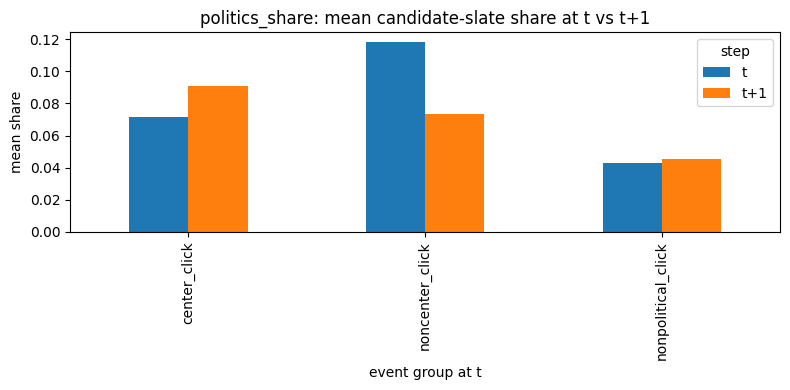

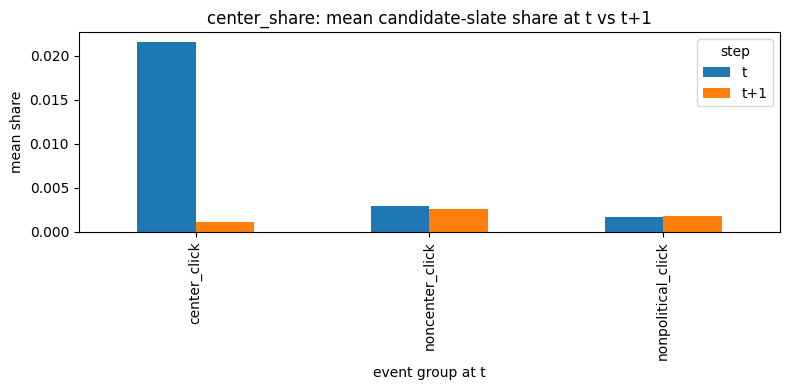

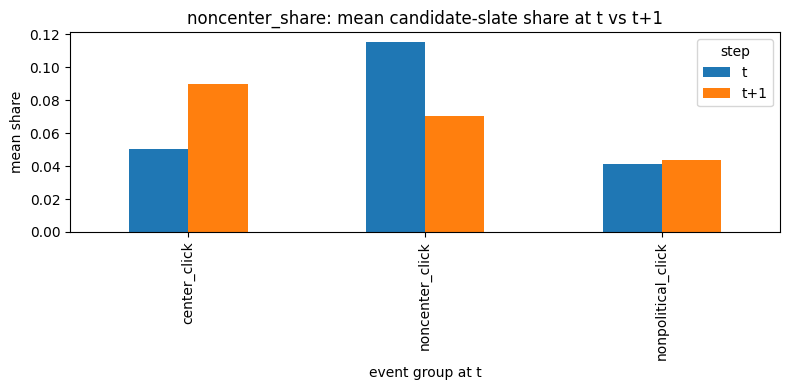

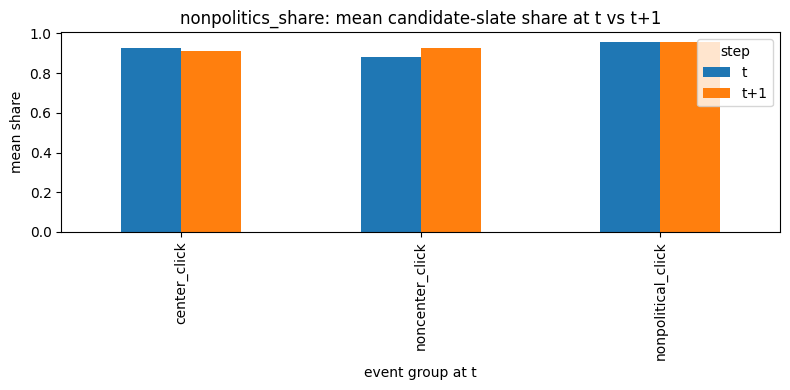

In [ ]:
def slate_metrics(imp_id):
    cands = impression_candidates.get(imp_id, [])
    n_total = len(cands)
    if n_total == 0:
        return {
            "n_candidates": 0,
            "politics_n": 0,
            "center_n": 0,
            "noncenter_n": 0,
            "unknown_pol_n": 0,
            "nonpolitics_n": 0,
            "politics_share": np.nan,
            "center_share": np.nan,
            "noncenter_share": np.nan,
            "nonpolitics_share": np.nan,
            "center_within_politics": np.nan,
        }

    is_pol = np.array([bool(is_politics_news_id(nid)) for nid in cands], dtype=bool)
    pol_n = int(is_pol.sum())
    nonpol_n = int((~is_pol).sum())

    ideos = [ideology_used_map.get(nid, None) for nid in cands]
    center_n = int(sum((ideos[i] == "center") and is_pol[i] for i in range(n_total)))
    noncenter_n = int(sum((ideos[i] == "non_center") and is_pol[i] for i in range(n_total)))

    labeled_pol = int(sum((ideos[i] is not None) and is_pol[i] for i in range(n_total)))
    unknown_pol_n = pol_n - labeled_pol

    return {
        "n_candidates": n_total,
        "politics_n": pol_n,
        "center_n": center_n,
        "noncenter_n": noncenter_n,
        "unknown_pol_n": unknown_pol_n,
        "nonpolitics_n": nonpol_n,
        "politics_share": pol_n / n_total,
        "center_share": center_n / n_total,
        "noncenter_share": noncenter_n / n_total,
        "nonpolitics_share": nonpol_n / n_total,
        "center_within_politics": (center_n / pol_n) if pol_n > 0 else np.nan,
    }


event_groups = ["center_click", "noncenter_click", "nonpolitical_click"]
evt = imp_df.loc[imp_df["event_group_t"].isin(event_groups)].copy()
evt = evt.dropna(subset=["imp_t1"]).copy()  

t_rows = []
for _, r in evt.iterrows():
    m = slate_metrics(r["impression_id"] if "impression_id" in evt.columns else r[evt.columns[0]])
    m["step"] = 0
    m["group"] = r["event_group_t"]
    t_rows.append(m)

t1_rows = []
for _, r in evt.iterrows():
    m = slate_metrics(r["imp_t1"])
    m["step"] = 1
    m["group"] = r["event_group_t"]
    t1_rows.append(m)

df_steps = pd.DataFrame(t_rows + t1_rows)

print("Cohort sizes (events with t+1 available):")
display(evt["event_group_t"].value_counts())


metrics = [
    "politics_share",
    "center_share",
    "noncenter_share",
    "nonpolitics_share",
    "center_within_politics",
    "unknown_pol_n"
]

summary = (
    df_steps.groupby(["group", "step"])[metrics + ["n_candidates", "politics_n", "center_n", "noncenter_n", "nonpolitics_n"]]
    .mean(numeric_only=True)
    .reset_index()
)

wide = summary.pivot(index="group", columns="step")
wide.columns = [f"{col}_t" if step == 0 else f"{col}_t1" for col, step in wide.columns]
wide = wide.sort_index()

delta = pd.DataFrame(index=wide.index)
for m in metrics:
    if f"{m}_t" in wide.columns and f"{m}_t1" in wide.columns:
        delta[f"delta_{m}"] = wide[f"{m}_t1"] - wide[f"{m}_t"]

print("\nMean slate composition at t and t+1:")
display(wide.round(4))

print("\nDelta (t+1 - t):")
display(delta.round(4))


plot_metrics = ["politics_share", "center_share", "noncenter_share", "nonpolitics_share"]

for m in plot_metrics:
    pivot = df_steps.groupby(["group", "step"])[m].mean().unstack("step")
    pivot = pivot.reindex(event_groups) 

    ax = pivot.plot(kind="bar", figsize=(8,4))
    ax.set_title(f"{m}: mean candidate-slate share at t vs t+1")
    ax.set_xlabel("event group at t")
    ax.set_ylabel("mean share")
    ax.legend(["t", "t+1"], title="step")
    plt.tight_layout()
    plt.show()


### Event study (t → t+1): does a click change the *candidate slate* ideology mix?

Let's split DEV impressions into 3 cohorts based on what was clicked at time **t**:

- **center_click**: at least one clicked item at *t* is political and labeled **center**
- **noncenter_click**: at least one clicked item at *t* is political and labeled **non_center**, and **no** center item was clicked
- **nonpolitical_click**: clicked items at *t* are **non-political** (no ideology label)

For each cohort we compare the **mean composition of the candidate slate** at time **t** versus the next impression **t+1** for the same user:
- `politics_share`: share of candidates that are political (center or non_center)
- `center_share`, `noncenter_share`, `nonpolitics_share`
- `center_within_politics`: among political candidates only, how many are center

> **Important caveat (sample size):** `center_click` has **only 28** events, so its estimates are noisy and should be interpreted cautiously.

### What is observed

**1) Center underrepresentation is visible immediately**
- Even when the user clicks center content (`center_click`), center is still a *tiny* fraction of the candidate slate.
- In the *baseline* cohort (`nonpolitical_click`), `center_share` is ~0.17–0.18% of the slate, while `noncenter_share` is ~4.1–4.4%.
- This matches what we saw earlier: within political items, the catalog is ~92% non_center vs ~8% center, so center is structurally scarce.

**2) After a center click, center does *not* increase at t+1 (it drops), while non_center rises** but it still increased politics in general at (t+1)
- `center_click` cohort:
  - `center_share` **decreases** strongly from *t* to *t+1* (≈ -2.05 percentage points).
  - `noncenter_share` **increases** (≈ +3.98 pp).
  - `center_within_politics` also **drops** sharply (≈ -0.348).
- Interpretation: clicking center does **not** lead to more center candidates next; if anything, the next slate becomes *more* non_center-heavy.
- Because the cohort is small, we treat this as *evidence of no positive reinforcement for center*, rather than a definitive negative effect.

**3) After a non_center click, political exposure *decreases* at t+1**
- `noncenter_click` cohort:
  - `politics_share` decreases (≈ -4.52 pp) and `nonpolitics_share` increases (≈ +4.52 pp).
  - Within politics, center’s share barely changes (very small delta), meaning the mix remains dominated by non_center whenever politics appears.
- Interpretation: a non_center click does not necessarily increase overall political exposure in the *candidate set* at the very next step; instead, the slate shifts slightly toward non-politics.  
  This suggests that any “reinforcement” may not happen via *more* politics candidates at t+1, but rather via **what gets ranked highly** (Top-K) or via longer-term dynamics (t+2, t+3, etc.).

**4) After a non-political click, almost nothing changes**
- `nonpolitical_click` cohort is large (21,810 events), and the deltas are tiny:
  - `politics_share` +0.27 pp, `center_share` +0.01 pp, `noncenter_share` +0.26 pp
- Interpretation: the system’s candidate distribution is relatively stable when users engage with non-political content.

### What this implies about reinforcement and underrepresentation

- **Underrepresentation:** Center content is consistently rare in the candidate slate across cohorts. Even in situations where users click center, the next impression does not show an increase in center availability.
- **Reinforcement (short-term, candidate stage):** We do **not** see clear short-term reinforcement toward center in the candidate pool. If reinforcement exists, it is more likely happening at:
  - the **ranking stage** (Top-K selection), where we previously saw center “disappear”, and/or
  - a **longer horizon** (multiple steps ahead), not just t+1.


### Stopping point and limitations

At this stage, the center vs non_center analysis already supports three robust conclusions:

1) **Center is structurally underrepresented** in the political catalog and in the candidate slates.
2) The **ranking step further reduces center visibility** (center is present in candidates but often disappears in Top-K).
3) In the **short-term event study (t → t+1) at the candidate stage**, we do not observe clear reinforcement toward center after center clicks.

A key limitation is statistical power: **center-click events are rare** (only a few dozen), which makes fine-grained analyses (e.g., “two consecutive center clicks”, longer horizons t+2/t+3) unstable and hard to justify.  
For that reason, I keep the main claims focused on: catalog/candidate underrepresentation, ranking suppression, and a cautious t→t+1 event study.


### Appendix: light left/right/center exploration

3-class labeled items (after optional HC filter): 1675
3-class coverage within political candidates: 0.633
3-class distribution within labeled political candidates:


,percent
right,65.87
left,25.84
center,8.29


3-class coverage within political Top-10: 0.715
3-class distribution within labeled political Top-10:


,percent
right,79.97
left,18.33
center,1.70


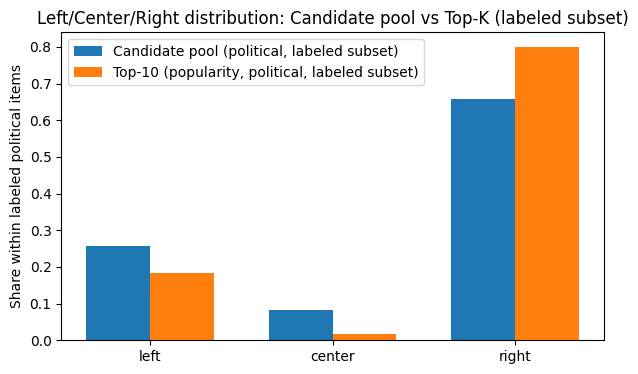

Delta (Top-K minus Candidate) in percentage points (labeled subset only):


,delta_pp
left,-7.51
center,-6.59
right,14.10


In [ ]:
POL_TRAIN_PATH = PROCESSED / "political_ideology_train.pkl"
POL_DEV_PATH   = PROCESSED / "political_ideology_dev.pkl"

pol_train = pd.read_pickle(POL_TRAIN_PATH)
pol_dev   = pd.read_pickle(POL_DEV_PATH)

HC_THR = 0.55 if "ideology_conf" in pol_train.columns else None

def build_3class_map(df, thr=None):
    use = df.copy()
    if thr is not None and "ideology_conf" in use.columns:
        use = use.loc[use["ideology_conf"] >= thr].copy()

    if "ideology_pred" not in use.columns:
        return {}

    return dict(zip(use["news_id"], use["ideology_pred"]))

ideo3_map = {}
ideo3_map.update(build_3class_map(pol_train, thr=HC_THR))
ideo3_map.update(build_3class_map(pol_dev,   thr=HC_THR))

print("3-class labeled items (after optional HC filter):", len(ideo3_map))

def dist_in_candidate_pool(max_impressions=20000):
    ids = impression_candidates.index[:max_impressions]
    rows = []
    for imp_id in ids:
        cands = impression_candidates.get(imp_id, [])
        for nid in cands:
            if ideology_used_map.get(nid, None) is None:
                continue
            lab3 = ideo3_map.get(nid, None)
            rows.append(lab3)  
    s = pd.Series(rows, dtype="object")

    cov = s.notna().mean() if len(s) else np.nan

    dist = s.dropna().value_counts(normalize=True)

    return cov, dist

cov_cand, dist_cand = dist_in_candidate_pool(max_impressions=20000)
print(f"3-class coverage within political candidates: {cov_cand:.3f}")
print("3-class distribution within labeled political candidates:")
display((dist_cand * 100).round(2).to_frame("percent"))


K = 10
MAX_IMP = 20000

def dist_in_topk(score_fn, k=10, max_impressions=20000):
    ids = impression_candidates.index[:max_impressions]
    labs = []
    for imp_id in ids:
        cands = impression_candidates.get(imp_id, [])
        if not cands:
            continue
        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)
        top = [cands[i] for i in order[:k]]

        for nid in top:
            if ideology_used_map.get(nid, None) is None:
                continue
            lab3 = ideo3_map.get(nid, None)
            labs.append(lab3)

    s = pd.Series(labs, dtype="object")
    cov = s.notna().mean() if len(s) else np.nan
    dist = s.dropna().value_counts(normalize=True)
    return cov, dist

cov_topk, dist_topk = dist_in_topk(pop_score_fn, k=K, max_impressions=MAX_IMP)
print(f"3-class coverage within political Top-{K}: {cov_topk:.3f}")
print(f"3-class distribution within labeled political Top-{K}:")
display((dist_topk * 100).round(2).to_frame("percent"))

labels = ["left", "center", "right"]
cand_vals = [float(dist_cand.get(l, 0.0)) for l in labels]
topk_vals = [float(dist_topk.get(l, 0.0)) for l in labels]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - w/2, cand_vals, width=w, label="Candidate pool (political, labeled subset)")
plt.bar(x + w/2, topk_vals, width=w, label=f"Top-{K} (popularity, political, labeled subset)")
plt.xticks(x, labels)
plt.ylabel("Share within labeled political items")
plt.title("Left/Center/Right distribution: Candidate pool vs Top-K (labeled subset)")
plt.legend()
plt.show()


def pp(a, b): 
    return (b - a) * 100

delta_pp = {l: pp(cand_vals[i], topk_vals[i]) for i, l in enumerate(labels)}
print("Delta (Top-K minus Candidate) in percentage points (labeled subset only):")
display(pd.Series(delta_pp).round(2).to_frame("delta_pp"))


### (3-class): Candidate pool vs Top-10 (left/center/right)

I restrict this analysis to political items that have a 3-class label (left/center/right).
Coverage is partial: ~63% of political candidates and ~72% of political Top-10 items are labeled, so results are interpreted as a *diagnostic* on the labeled subset.

**Candidate pool (labeled political subset):**
- Right: 65.9%, Left: 25.8%, Center: 8.3%

**Top-10 (labeled political subset):**
- Right: 80.0%, Left: 18.3%, Center: 1.7%

**Ranking shift (Top-10 − candidates, percentage points):**
- Right: +14.1 pp, Left: −7.5 pp, Center: −6.6 pp

**Interpretation:** even within the political subset, the ranking stage substantially increases exposure to right-leaning items and sharply reduces center (which almost disappears in Top-10) and left. This supports the earlier observation that center is not only scarce in the pool, but also *further suppressed by ranking*, creating conditions that can reinforce one-sided exposure over time.


Underrepresentation: Center is already limited in the candidate pool (~8.3% of labeled political candidates) and Left also is limited, so they start in disadvantage.

Ranking amplification: The shift from 8.3% → 1.7% for center, 25.8% → 18.3% for left (and 65.9% → 80.0% for right) suggests that even when center and left exist as an option, the ranking stage strongly deprioritizes them.

Reinforcement risk: If users mostly get exposed to right-leaning political items in Top-10, they’re more likely to click them, which can create a feedback loop (more right exposure → more right clicks → more right exposure).

### Left / Center / Right: Candidate pool vs Top-K (ranking amplification)

In this section let's measure how the **ranking step** changes the ideological mix **within political content** using the **3-class labels (left / center / right)**.

Let's compare:
- **Candidate pool distribution**: ideology shares among *political items that have a 3-class label* (what is available to rank).
- **Top-K distribution**: ideology shares among the *political items that actually appear in the ranked Top-K* (what gets exposed).
- We repeat for **K = 5, 10, 20** and compute **bootstrap 95% confidence intervals** for  
  Delta_{pp} = Top-K share- Candidate share (in percentage points).

> This is not an accuracy test. It quantifies **exposure shift caused by ranking** relative to what was available.


In [ ]:
CLASSES = ["left", "center", "right"]
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}

def _counts_3class_from_news_ids(news_ids, ideology_used_map, ideology_3class_map):
    """
    Count left/center/right among items that are:
      (1) political per ideology_used_map (not None)
      (2) have a 3-class label in CLASSES per ideology_3class_map
    Returns:
      counts (3,), n_pol, n_pol_labeled
    """
    counts = np.zeros(3, dtype=np.int32)
    n_pol = 0
    n_pol_labeled = 0

    for nid in news_ids:
        if ideology_used_map.get(nid, None) is None:
            continue
        n_pol += 1
        lab = ideology_3class_map.get(nid, None)
        if lab in CLASS_TO_IDX:
            counts[CLASS_TO_IDX[lab]] += 1
            n_pol_labeled += 1

    return counts, n_pol, n_pol_labeled


def precompute_impression_mats(score_fn, k, max_impressions=None):
    """
    Precompute per-impression:
      - candidate 3-class counts (political+labeled)
      - top-k 3-class counts (political+labeled)
      - candidate political count, candidate political labeled count
      - top-k political count, top-k political labeled count
    """
    imp_ids = impression_candidates.index
    if max_impressions is not None:
        imp_ids = imp_ids[:max_impressions]

    n = len(imp_ids)
    cand_counts = np.zeros((n, 3), dtype=np.int32)
    topk_counts = np.zeros((n, 3), dtype=np.int32)

    cand_pol = np.zeros(n, dtype=np.int32)
    cand_pol_lab = np.zeros(n, dtype=np.int32)
    topk_pol = np.zeros(n, dtype=np.int32)
    topk_pol_lab = np.zeros(n, dtype=np.int32)

    for i, imp_id in enumerate(imp_ids):
        cands = impression_candidates[imp_id]
        cc, n_pol, n_pol_lab = _counts_3class_from_news_ids(
            cands, ideology_used_map, ideology_3class_map
        )
        cand_counts[i] = cc
        cand_pol[i] = n_pol
        cand_pol_lab[i] = n_pol_lab

        if len(cands) == 0:
            continue
        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)
        top = [cands[j] for j in order[:k]]

        tc, n_pol_t, n_pol_lab_t = _counts_3class_from_news_ids(
            top, ideology_used_map, ideology_3class_map
        )
        topk_counts[i] = tc
        topk_pol[i] = n_pol_t
        topk_pol_lab[i] = n_pol_lab_t

    return imp_ids, cand_counts, topk_counts, cand_pol, cand_pol_lab, topk_pol, topk_pol_lab


def _props_from_counts(counts_3):
    s = counts_3.sum()
    if s == 0:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return counts_3 / s


def summarize_point_estimate(cand_counts, topk_counts, cand_pol, cand_pol_lab, topk_pol, topk_pol_lab):
    """
    Global (pooled) estimate across impressions by summing counts.
    """
    cand_sum = cand_counts.sum(axis=0)
    topk_sum = topk_counts.sum(axis=0)

    cand_prop = _props_from_counts(cand_sum)
    topk_prop = _props_from_counts(topk_sum)
    delta_pp = (topk_prop - cand_prop) * 100.0

    cand_cov = (cand_pol_lab.sum() / cand_pol.sum()) if cand_pol.sum() > 0 else np.nan
    topk_cov = (topk_pol_lab.sum() / topk_pol.sum()) if topk_pol.sum() > 0 else np.nan

    out = pd.DataFrame({
        "candidate_%": cand_prop * 100,
        "topk_%": topk_prop * 100,
        "delta_pp": delta_pp
    }, index=CLASSES)

    meta = {
        "labeled_3class_items_candidate": int(cand_sum.sum()),
        "labeled_3class_items_topk": int(topk_sum.sum()),
        "3class_coverage_within_political_candidates": float(cand_cov),
        "3class_coverage_within_political_topk": float(topk_cov),
        "total_political_candidates": int(cand_pol.sum()),
        "total_political_topk": int(topk_pol.sum()),
    }
    return out, meta


def bootstrap_delta_pp(cand_counts, topk_counts, n_boot=1000, seed=42):
    """
    Bootstrap over impressions, recompute pooled proportions and delta_pp.
    Returns CI for delta_pp per class.
    """
    rng = np.random.default_rng(seed)
    n = cand_counts.shape[0]
    deltas = np.zeros((n_boot, 3), dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  
        cand_sum = cand_counts[idx].sum(axis=0)
        topk_sum = topk_counts[idx].sum(axis=0)

        cand_prop = _props_from_counts(cand_sum)
        topk_prop = _props_from_counts(topk_sum)
        deltas[b] = (topk_prop - cand_prop) * 100.0

    ci_low = np.nanquantile(deltas, 0.025, axis=0)
    ci_high = np.nanquantile(deltas, 0.975, axis=0)
    mean_delta = np.nanmean(deltas, axis=0)

    return pd.DataFrame({
        "delta_pp_boot_mean": mean_delta,
        "ci95_low": ci_low,
        "ci95_high": ci_high
    }, index=CLASSES)



K_LIST = [5, 10, 20]
MAX_IMP = None  

results_by_k = {}
ci_by_k = {}
meta_by_k = {}

for K in K_LIST:
    imp_ids, candC, topC, cand_pol, cand_pol_lab, top_pol, top_pol_lab = precompute_impression_mats(
        pop_score_fn, k=K, max_impressions=MAX_IMP
    )

    point_df, meta = summarize_point_estimate(candC, topC, cand_pol, cand_pol_lab, top_pol, top_pol_lab)
    ci_df = bootstrap_delta_pp(candC, topC, n_boot=1000, seed=42)

    results_by_k[K] = point_df
    ci_by_k[K] = ci_df
    meta_by_k[K] = meta

    print(f"\n=== K={K} ===")
    print("Meta:", meta)
    display(point_df)
    display(ci_df)

delta_compact = pd.concat(
    {K: results_by_k[K]["delta_pp"] for K in K_LIST},
    axis=1
)
delta_compact.columns = [f"delta_pp_K{K}" for K in K_LIST]
print("\nDelta_pp across K:")
display(delta_compact)



=== K=5 ===
Meta: {'labeled_3class_items_candidate': 135527, 'labeled_3class_items_topk': 6555, '3class_coverage_within_political_candidates': 1.0, '3class_coverage_within_political_topk': 1.0, 'total_political_candidates': 135527, 'total_political_topk': 6555}


,candidate_%,topk_%,delta_pp
left,37.118803,24.485126,-12.633677
center,5.688903,1.311976,-4.376928
right,57.192294,74.202899,17.010605


,delta_pp_boot_mean,ci95_low,ci95_high
left,-12.654648,-13.785250,-11.487767
center,-4.373564,-4.650239,-4.058643
right,17.028212,15.858608,18.174737



=== K=10 ===
Meta: {'labeled_3class_items_candidate': 135527, 'labeled_3class_items_topk': 15659, '3class_coverage_within_political_candidates': 1.0, '3class_coverage_within_political_topk': 1.0, 'total_political_candidates': 135527, 'total_political_topk': 15659}


,candidate_%,topk_%,delta_pp
left,37.118803,32.894821,-4.223982
center,5.688903,1.487962,-4.200941
right,57.192294,65.617217,8.424923


...


=== K=20 ===
Meta: {'labeled_3class_items_candidate': 135527, 'labeled_3class_items_topk': 33530, '3class_coverage_within_political_candidates': 1.0, '3class_coverage_within_political_topk': 1.0, 'total_political_candidates': 135527, 'total_political_topk': 33530}


,candidate_%,topk_%,delta_pp
left,37.118803,35.466746,-1.652057
center,5.688903,2.657322,-3.031582
right,57.192294,61.875932,4.683638


,delta_pp_boot_mean,ci95_low,ci95_high
left,-1.653601,-2.136453,-1.151337
center,-3.032120,-3.191348,-2.870518
right,4.685721,4.193701,5.158562



Delta_pp across K:


,delta_pp_K5,delta_pp_K10,delta_pp_K20
left,-12.633677,-4.223982,-1.652057
center,-4.376928,-4.200941,-3.031582
right,17.010605,8.424923,4.683638


### Interpretation

- The candidate pool is already imbalanced (within labeled political items):
  - **Right ≈ 57.2%**, **Left ≈ 37.1%**, **Center ≈ 5.7%**.

- Ranking consistently **amplifies Right** and **suppresses Left and (especially) Center**:
  - **K=5:** Right **+17.0 pp**, Left **−12.6 pp**, Center **−4.38 pp**
  - **K=10:** Right **+8.42 pp**, Left **−4.22 pp**, Center **−4.20 pp**
  - **K=20:** Right **+4.68 pp**, Left **−1.65 pp**, Center **−3.03 pp**

- **Center is disproportionately penalized**:
  - Even though Center is ~5.7% of political candidates, it drops to **~1.31% (Top-5)**, **~1.49% (Top-10)**, **~2.66% (Top-20)**.
  - Because the baseline is small, these negative deltas represent a large *relative* reduction in center exposure.

- The bootstrap **95% CIs do not cross 0** for any class in any K, suggesting the shifts are **robust** (not explained by sampling noise).

**Bottom line:** part of the imbalance comes from **catalog availability**, but the **ranking stage further amplifies** it—pushing political exposure toward **Right** and away from **Left/Center**, with **Center** being the most suppressed.


### Ranking shift (Candidates → Top-K) by user group (3-class ideology)

Up to now, I mostly used the **binary** label (`center` vs `non_center`) because the 3-class labels (left/center/right) are sparser.
Here let's do a **lightweight 3-class check** to see whether the **ranking step** (selecting the Top-K items) changes the ideology mix compared to what was available in the candidate pool.

**What is computed**
For each impression (and for each user group), let's compare:
- `candidate_%`: ideology distribution among political **candidates**
- `topk_%`: ideology distribution among political items that actually appear in **Top-K**
- `delta_pp = topk_% − candidate_%` (in percentage points)

> Note: this analysis is restricted to the **3-class labeled subset** of political items, so it describes ranking behavior *conditional on 3-class coverage*.


In [ ]:
def summarize_by_group(imp_ids, cand_counts, topk_counts):
    groups = np.array([user_group(imp_user[iid]) for iid in imp_ids], dtype=object)

    rows = []
    for g in pd.unique(groups):
        mask = (groups == g)
        cand_sum = cand_counts[mask].sum(axis=0)
        top_sum = topk_counts[mask].sum(axis=0)

        cand_prop = _props_from_counts(cand_sum)
        top_prop = _props_from_counts(top_sum)
        delta_pp = (top_prop - cand_prop) * 100.0

        rows.append(pd.DataFrame({
            "group": g,
            "candidate_%": cand_prop * 100,
            "topk_%": top_prop * 100,
            "delta_pp": delta_pp
        }, index=CLASSES))

    out = pd.concat(rows).reset_index(names="class")
    return out.sort_values(["group","class"])

K = 10
imp_ids, candC, topC, *_ = precompute_impression_mats(pop_score_fn, k=K, max_impressions=MAX_IMP)
group_df = summarize_by_group(imp_ids, candC, topC)
display(group_df)


,class,group,candidate_%,topk_%,delta_pp
7,center,engaged_no_center_clicks,5.546751,1.010101,-4.536650
6,left,engaged_no_center_clicks,37.559429,33.333333,-4.226096
8,right,engaged_no_center_clicks,56.893819,65.656566,8.762746
4,center,engaged_with_center_clicks,5.069124,2.439024,-2.630100
3,left,engaged_with_center_clicks,33.640553,34.146341,0.505788
5,right,engaged_with_center_clicks,61.290323,63.414634,2.124312
1,center,other,5.690568,1.488498,-4.202070
0,left,other,37.122343,32.888717,-4.233626
2,right,other,57.187089,65.622785,8.435696


### Interpretation (3-class ranking shift results)

Across all groups, the **Top-K list is more right-leaning than the candidate pool**:

- **Right is amplified by ranking** (positive `delta_pp`):
  - `other`: right increases from ~57.19% → ~65.62% (**+8.44 pp**)
  - `engaged_no_center_clicks`: ~56.89% → ~65.66% (**+8.76 pp**)
  - `engaged_with_center_clicks`: ~61.29% → ~63.41% (**+2.12 pp**)

- **Center is suppressed by ranking** (negative `delta_pp`):
  - `other`: ~5.69% → ~1.49% (**−4.20 pp**)
  - `engaged_no_center_clicks`: ~5.55% → ~1.01% (**−4.54 pp**)
  - `engaged_with_center_clicks`: ~5.07% → ~2.44% (**−2.63 pp**)

- **Left is also (usually) reduced**:
  - `other`: **−4.23 pp**
  - `engaged_no_center_clicks`: **−4.23 pp**
  - `engaged_with_center_clicks`: roughly stable / slightly positive (**+0.51 pp**), but the group is much smaller.

**Takeaway:** even when center (and left) exist in the candidate pool, they become **much rarer in the ranked Top-K**, while right becomes **more prevalent**.  
This supports the earlier conclusion that **underrepresentation is not only a catalog/candidate availability issue** - the **ranking step further amplifies** the imbalance.


---------------------------------

## Notebook 07 - Conclusions (Ideology bias & reinforcement)

### What we established (robust findings)

**1) Center is structurally underrepresented (supply problem)**
- The political catalog / labels are heavily imbalanced: *center is rare* compared to *non-center*.
- This imbalance propagates into the candidate pool: even before ranking, the system typically has only **~3 political candidates per impression**, and **far below 1 expected center candidate** per impression on average.
- As a result, many impressions contain **zero center candidates**, making “center exposure” impossible regardless of the ranking method.

**2) Ranking further suppresses center (selection problem)**
- When we compare *candidate composition* vs *Top-K composition*, we observe a consistent **drop in center share** from candidates → Top-K.
- This indicates the “center disappearance” is not explained by catalog imbalance alone: **ranking amplifies the skew** by selecting center even less often than its availability would suggest.

**3) Short-term reinforcement at the candidate stage is not clearly supported (t → t+1 event study)**
- In the event study (conditioning on what was clicked at time t), we do **not** observe strong evidence that a **center click increases center availability** in the candidate slate at t+1.
- If reinforcement exists, our evidence suggests it is more likely happening through:
  - the **ranking stage** (Top-K selection), and/or
  - **longer horizons** (t+2, t+3), which we cannot study reliably here due to data sparsity.

### Light 3-class extension (left / center / right)

- Within labeled political candidates, the distribution is already skewed (right > left > center).
- In Top-K, the skew becomes stronger: **right increases**, while **left and center decrease**.
- This pattern persists across K (e.g., K=5/10/20), indicating a stable ranking amplification effect, not just noise from one specific cutoff.

### Main takeaway (what “bias” means here)

The dominance of non-center (and, in the 3-class view, right-leaning) content in recommendations is driven by **two compounding mechanisms**:
1) **Underrepresentation in the supply/candidate stage** (center often not even present),
2) **Amplification at ranking time** (center/left chosen less than their candidate share).

### Stopping point & limitations (why we stop here)

- **Statistical power**: center-click events are extremely rare, making t+2/t+3 or “two consecutive center clicks” analyses unstable and hard to justify.
- **Label coverage/quality**: ideology labels exist only for a subset (political items) and may contain noise; conclusions should be framed as “within labeled political content”.
- Therefore, we keep the main claims focused on: **catalog/candidate underrepresentation**, **ranking suppression**, and a **cautious t→t+1 event study**.


-----------------------------------------------

## Notebook 08 - Wrap-up, mitigations, and project conclusions

This final notebook will consolidate findings across the project and translate them into **actionable mitigation ideas**, while explicitly checking any remaining assignment requirements.



#### Mitigation proposals (mapped to the two mechanisms)

**A) Candidate-stage mitigations (fix the “availability bottleneck”)**
- Candidate diversification: ensure political candidate pools contain some ideological variety when possible.
- Minimum-coverage rule: if politics is being recommended, try to include at least one “rare class” candidate when available.
- Sampling/retrieval adjustments: increase retrieval probability for underrepresented political classes.

**B) Ranking-stage mitigations (fix the “amplification”)**
- Re-ranking with constraints: enforce soft/ hard bounds on ideology proportions in Top-K (within labeled political subset).
- Diversity-aware objectives: penalize concentration (e.g., repeated ideology) while maintaining relevance.
- Calibration / uncertainty filtering: reduce the impact of low-confidence ideology labels when applying constraints.
